### Salary prediction, episode II: make it actually work (4 points)

Your main task is to use some of the tricks you've learned on the network and analyze if you can improve __validation MAE__. Try __at least 3 options__ from the list below for a passing grade. Write a short report about what you have tried. More ideas = more bonus points.

__Please be serious:__ " plot learning curves in MAE/epoch, compare models based on optimal performance, test one change at a time. You know the drill :)

You can use either __pytorch__ or __tensorflow__ or any other framework (e.g. pure __keras__). Feel free to adapt the seminar code for your needs. For tensorflow version, consider `seminar_tf2.ipynb` as a starting point.


In [ ]:
# < A whole lot of your code > - models, charts, analysis

### A short report

Please tell us what you did and how did it work.

`<YOUR_TEXT_HERE>`, i guess...

## Recommended options

#### A) CNN architecture

All the tricks you know about dense and convolutional neural networks apply here as well.
* Dropout. Nuff said.
* Batch Norm. This time it's `nn.BatchNorm*`/`L.BatchNormalization`
* Parallel convolution layers. The idea is that you apply several nn.Conv1d to the same embeddings and concatenate output channels.
* More layers, more neurons, ya know...


#### B) Play with pooling

There's more than one way to perform pooling:
* Max over time (independently for each feature)
* Average over time (excluding PAD)
* Softmax-pooling:
$$ out_{i, t} = \sum_t {h_{i,t} \cdot {{e ^ {h_{i, t}}} \over \sum_\tau e ^ {h_{j, \tau}} } }$$

* Attentive pooling
$$ out_{i, t} = \sum_t {h_{i,t} \cdot Attn(h_t)}$$

, where $$ Attn(h_t) = {{e ^ {NN_{attn}(h_t)}} \over \sum_\tau e ^ {NN_{attn}(h_\tau)}}  $$
and $NN_{attn}$ is a dense layer.

The optimal score is usually achieved by concatenating several different poolings, including several attentive pooling with different $NN_{attn}$ (aka multi-headed attention).

The catch is that keras layers do not inlude those toys. You will have to [write your own keras layer](https://keras.io/layers/writing-your-own-keras-layers/). Or use pure tensorflow, it might even be easier :)

#### C) Fun with words

It's not always a good idea to train embeddings from scratch. Here's a few tricks:

* Use a pre-trained embeddings from `gensim.downloader.load`. See last lecture.
* Start with pre-trained embeddings, then fine-tune them with gradient descent. You may or may not download pre-trained embeddings from [here](http://nlp.stanford.edu/data/glove.6B.zip) and follow this [manual](https://keras.io/examples/nlp/pretrained_word_embeddings/) to initialize your Keras embedding layer with downloaded weights.
* Use the same embedding matrix in title and desc vectorizer


#### D) Going recurrent

We've already learned that recurrent networks can do cool stuff in sequence modelling. Turns out, they're not useless for classification as well. With some tricks of course..

* Like convolutional layers, LSTM should be pooled into a fixed-size vector with some of the poolings.
* Since you know all the text in advance, use bidirectional RNN
  * Run one LSTM from left to right
  * Run another in parallel from right to left
  * Concatenate their output sequences along unit axis (dim=-1)

* It might be good idea to mix convolutions and recurrent layers differently for title and description


#### E) Optimizing seriously

* You don't necessarily need 100 epochs. Use early stopping. If you've never done this before, take a look at [early stopping callback(keras)](https://keras.io/callbacks/#earlystopping) or in [pytorch(lightning)](https://pytorch-lightning.readthedocs.io/en/latest/common/early_stopping.html).
  * In short, train until you notice that validation
  * Maintain the best-on-validation snapshot via `model.save(file_name)`
  * Plotting learning curves is usually a good idea
  
Good luck! And may the force be with you!

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
data = pd.read_csv("/content/drive/MyDrive/nlp_course/Train_rev1.zip", compression='zip', index_col=None)
data.shape

(244768, 12)

In [ ]:
data['Log1pSalary'] = np.log1p(data['SalaryNormalized']).astype('float32')


In [ ]:
text_columns = ["Title", "FullDescription"]
categorical_columns = ["Category", "Company", "LocationNormalized", "ContractType", "ContractTime"]
TARGET_COLUMN = "Log1pSalary"

data[categorical_columns] = data[categorical_columns].fillna('NaN') # cast missing values to string "NaN"

data.sample(3)

,Id,Title,FullDescription,LocationRaw,LocationNormalized,ContractType,ContractTime,Company,Category,SalaryRaw,SalaryNormalized,SourceName,Log1pSalary
130948,70174743,Analyst/Programmer,We need two pragmatic analyst/programmers to e...,Oxford Oxfordshire South East,Oxford,NaN,permanent,"CTSU, University of Oxford",IT Jobs,"From 29,099 to 35,788 per annum",32443,cwjobs.co.uk,10.387271
220422,72372573,"Developer (EDI, XML, Web services)",My prestigious global client based in Dorset r...,Dorset,Dorset,NaN,permanent,IT Works Recruitment Ltd,IT Jobs,35000.00 - 40000.00 GBP Annual,37500,jobserve.com,10.532123
6277,62381550,Revenue Systems Analyst Agile,Introduction A Unique opportunity has become a...,City of London,The City,NaN,NaN,Matchtech Group plc.,Engineering Jobs,"35,000 - 45,000/yr",40000,rengineeringjobs.com,10.596660


In [ ]:
import nltk
#TODO YOUR CODE HERE

tokenizer = nltk.tokenize.WordPunctTokenizer()

def tokenize_to_str(text: str) -> str:
    text = str(text).lower()
    return " ".join(tokenizer.tokenize(text))

for col in ["Title", "FullDescription"]:
  data[col] = data[col].apply(tokenize_to_str)

In [ ]:
from collections import Counter
token_counts = Counter()

# Count how many times does each token occur in both "Title" and "FullDescription" in total
#TODO <YOUR CODE>
for col in ["Title", "FullDescription"]:
    for text in data[col].values:
        token_counts.update(text.split())

In [ ]:
min_count = 10

# tokens from token_counts keys that had at least min_count occurrences throughout the dataset
tokens = [t for t, cnt in token_counts.items() if cnt >= min_count]

# Add a special tokens for unknown and empty words
UNK, PAD = "UNK", "PAD"
tokens = [UNK, PAD] + tokens

In [ ]:
token_to_id = {token: i for i, token in enumerate(tokens)} #<your code here - dict of token name to its index in tokens>

In [ ]:
UNK_IX, PAD_IX = map(token_to_id.get, [UNK, PAD])

def as_matrix(sequences, max_len=None):
    """ Convert a list of tokens into a matrix with padding """
    if isinstance(sequences[0], str):
        sequences = list(map(str.split, sequences))

    max_len = min(max(map(len, sequences)), max_len or float('inf'))

    matrix = np.full((len(sequences), max_len), np.int32(PAD_IX))
    for i,seq in enumerate(sequences):
        row_ix = [token_to_id.get(word, UNK_IX) for word in seq[:max_len]]
        matrix[i, :len(row_ix)] = row_ix

    return matrix

In [ ]:
from sklearn.feature_extraction import DictVectorizer

# we only consider top-1k most frequent companies to minimize memory usage
top_companies, top_counts = zip(*Counter(data['Company']).most_common(1000))
recognized_companies = set(top_companies)
data["Company"] = data["Company"].apply(lambda comp: comp if comp in recognized_companies else "Other")

categorical_vectorizer = DictVectorizer(dtype=np.float32, sparse=False)
categorical_vectorizer.fit(data[categorical_columns].apply(dict, axis=1))

DictVectorizer(dtype=<class 'numpy.float32'>, sparse=False)

In [ ]:
from sklearn.model_selection import train_test_split

data_train, data_val = train_test_split(data, test_size=0.2, random_state=42)
data_train.index = range(len(data_train))
data_val.index = range(len(data_val))

print("Train size = ", len(data_train))
print("Validation size = ", len(data_val))

Train size =  195814
Validation size =  48954


In [ ]:
def to_tensors(batch, device):
    batch_tensors = dict()
    for key, arr in batch.items():
        if key in ["FullDescription", "Title"]:
            batch_tensors[key] = torch.tensor(arr, device=device, dtype=torch.int64)
        else:
            batch_tensors[key] = torch.tensor(arr, device=device)
    return batch_tensors


def make_batch(data, max_len=None, word_dropout=0, device=device):
    """
    Creates a keras-friendly dict from the batch data.
    :param word_dropout: replaces token index with UNK_IX with this probability
    :returns: a dict with {'title' : int64[batch, title_max_len]
    """
    batch = {}
    batch["Title"] = as_matrix(data["Title"].values, max_len)
    batch["FullDescription"] = as_matrix(data["FullDescription"].values, max_len)
    batch['Categorical'] = categorical_vectorizer.transform(data[categorical_columns].apply(dict, axis=1))

    if word_dropout != 0:
        batch["FullDescription"] = apply_word_dropout(batch["FullDescription"], 1. - word_dropout)

    if TARGET_COLUMN in data.columns:
        batch[TARGET_COLUMN] = data[TARGET_COLUMN].values

    return to_tensors(batch, device)

def apply_word_dropout(matrix, keep_prop, replace_with=UNK_IX, pad_ix=PAD_IX,):
    dropout_mask = np.random.choice(2, np.shape(matrix), p=[keep_prop, 1 - keep_prop])
    dropout_mask &= matrix != pad_ix
    return np.choose(dropout_mask, [matrix, np.full_like(matrix, replace_with)])

In [ ]:

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)


def iterate_minibatches(data, batch_size=256, shuffle=True, cycle=False, device=device, **kwargs):
    """Iterate minibatches of pandas DataFrame -> dict of torch tensors (via make_batch)."""
    while True:
        indices = np.arange(len(data))
        if shuffle:
            indices = np.random.permutation(indices)
        for start in range(0, len(indices), batch_size):
            batch = make_batch(data.iloc[indices[start:start+batch_size]], device=device, **kwargs)
            yield batch
        if not cycle:
            break

@torch.no_grad()
def eval_mae(model, data, batch_size=256, device=device, **kw):
    model.eval()
    abs_error = num_samples = 0.0
    for batch in iterate_minibatches(data, batch_size=batch_size, shuffle=False, device=device, **kw):
        pred = model(batch)
        abs_error += torch.sum(torch.abs(pred - batch[TARGET_COLUMN]))
        num_samples += len(pred)
    return (abs_error / num_samples).detach().cpu().item()


device: cpu


In [ ]:
from IPython.display import clear_output, display
import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
from tqdm.auto import tqdm
import torch.nn.functional as F


def fit_model(
    model,
    train_df,
    val_df,
    *,
    lr=1e-3,
    batch_size=128,
    max_epochs=10,
    steps_per_epoch=None,
    grad_clip=None,
    live_plot=True,
    verbose=True,
):
    model = model.to(device)
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    criterion = nn.MSELoss()

    if steps_per_epoch is None:
        steps_per_epoch = int(np.ceil(len(train_df) / batch_size))

    history = {"train_mse": [], "val_mae": []}

    train_iter = iterate_minibatches(
        train_df, batch_size=batch_size, shuffle=True, cycle=True, device=device
    )

    for epoch in range(1, max_epochs + 1):
        model.train()
        running_mse = 0.0

        for _ in tqdm(range(steps_per_epoch), desc=f"epoch {epoch}", leave=False):
            batch = next(train_iter)
            pred = model(batch)
            loss = criterion(pred, batch[TARGET_COLUMN])

            opt.zero_grad(set_to_none=True)
            loss.backward()
            if grad_clip is not None:
                nn.utils.clip_grad_norm_(model.parameters(), grad_clip)
            opt.step()

            running_mse += loss.detach().cpu().item()

        train_mse = running_mse / steps_per_epoch
        val_mae = eval_mae(model, val_df, batch_size=batch_size, device=device)

        history["train_mse"].append(train_mse)
        history["val_mae"].append(val_mae)

        if verbose:
            print(f"Epoch {epoch:03d} | train MSE {train_mse:.5f} | val MAE {val_mae:.5f}")

        if live_plot:
            clear_output(wait=True)
            epochs = np.arange(1, len(history["val_mae"]) + 1)

            fig, ax = plt.subplots(figsize=(8, 4))
            ax.plot(epochs, history["val_mae"], marker="o")
            ax.set_xlabel("epoch")
            ax.set_ylabel("val MAE")
            ax.grid(True)
            ax.set_title("Validation MAE (online)")
            display(fig)
            plt.close(fig)

    return model, history




# Option A


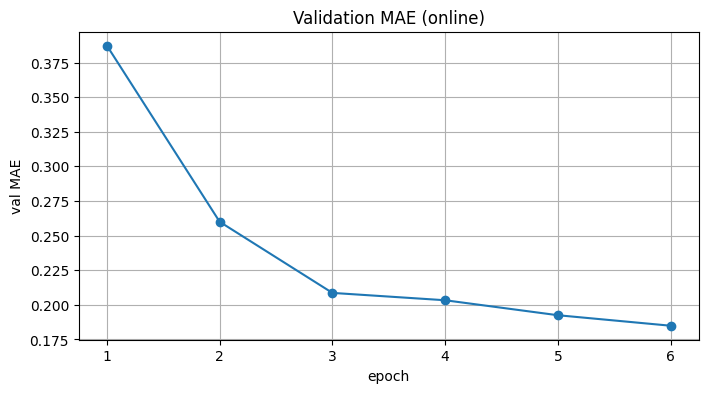

epoch 7:   0%|          | 0/1530 [00:00<?, ?it/s]

In [ ]:
# Option A: CNN
# - parallel conv (kernels 2/3/5)
# - batch norm
# - dropout after conv
# - a slightly deeper head

class ParallelCNNEncoder(nn.Module):
    def __init__(self, emb_layer: nn.Embedding, out_channels=96, kernels=(2,3,5), dropout=0.2):
        super().__init__()
        self.emb = emb_layer
        emb_size = emb_layer.embedding_dim

        self.convs = nn.ModuleList([
            nn.Conv1d(emb_size, out_channels, kernel_size=k, padding=k//2)
            for k in kernels
        ])
        self.bns = nn.ModuleList([nn.BatchNorm1d(out_channels) for _ in kernels])
        self.dropout = nn.Dropout(dropout)

        self.out_dim = out_channels * len(kernels)

    def forward(self, x):  # x: [B, T]
        e = self.emb(x).transpose(1,2)  # [B, E, T]
        parts = []
        for conv, bn in zip(self.convs, self.bns):
            h = conv(e)                  # [B, C, T]
            h = bn(h)
            h = F.relu(h)
            h = self.dropout(h)
            parts.append(torch.max(h, dim=2).values)  # [B, C]
        return torch.cat(parts, dim=1)   # [B, C*len(kernels)]


class SalaryPredictorA(nn.Module):
    def __init__(self, n_tokens=len(tokens), n_cat_features=len(categorical_vectorizer.vocabulary_), hid=128,
                 emb_size=64, cnn_channels=96, dropout=0.3):
        super().__init__()
        self.emb = nn.Embedding(n_tokens, emb_size, padding_idx=PAD_IX)

        # share embeddings between title/desc (also partially fits option C)
        self.title_enc = ParallelCNNEncoder(self.emb, out_channels=cnn_channels, kernels=(2,3,5), dropout=dropout)
        self.desc_enc  = ParallelCNNEncoder(self.emb, out_channels=cnn_channels, kernels=(2,3,5), dropout=dropout)

        self.cat_fc = nn.Sequential(
            nn.Linear(n_cat_features, hid),
            nn.BatchNorm1d(hid),
            nn.ReLU(),
            nn.Dropout(dropout),
        )

        feat_dim = self.title_enc.out_dim + self.desc_enc.out_dim + hid

        self.head = nn.Sequential(
            nn.Linear(feat_dim, hid),
            nn.BatchNorm1d(hid),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hid, hid//2),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hid//2, 1),
        )

    def forward(self, batch):
        title_vec = self.title_enc(batch["Title"])
        desc_vec  = self.desc_enc(batch["FullDescription"])
        cat_vec   = self.cat_fc(batch["Categorical"])

        x = torch.cat([title_vec, desc_vec, cat_vec], dim=1)
        return self.head(x).squeeze(1)


model_a = SalaryPredictorA()
model_a, hist_a = fit_model(model_a, data_train, data_val,
                           lr=2e-3,
                           batch_size=128, max_epochs=10, grad_clip=1.0)
plot_history(hist_a, "Option A: Parallel CNN + BN + Dropout")
print("Best val MAE (A):", eval_mae(model_a, data_val))


In [ ]:
!pip -q install plotly
import plotly.graph_objects as go

def cuboid_mesh(x0, y0, z0, dx, dy, dz, name):
    # 8 vertices of cuboid
    x = [x0, x0+dx, x0+dx, x0,   x0, x0+dx, x0+dx, x0]
    y = [y0, y0,    y0+dy, y0+dy,y0, y0,    y0+dy, y0+dy]
    z = [z0, z0,    z0,    z0,   z0+dz, z0+dz, z0+dz, z0+dz]

    # 12 triangles (2 per face)
    I = [0,0,0, 1,1,2, 4,4,5, 6,6,7]
    J = [1,2,3, 2,5,3, 5,6,6, 5,4,4]
    K = [2,3,0, 5,6,7, 6,7,4, 4,7,6]

    return go.Mesh3d(
        x=x, y=y, z=z,
        i=I, j=J, k=K,
        opacity=0.35,
        name=name,
        hovertext=name,
        hoverinfo="text"
    )

def label(x, y, z, text):
    return go.Scatter3d(
        x=[x], y=[y], z=[z],
        mode="text",
        text=[text],
        textposition="middle center",
        showlegend=False
    )

def arrow3d(x1,y1,z1, x2,y2,z2, text=None):
    # line + cone arrowhead
    line = go.Scatter3d(x=[x1,x2], y=[y1,y2], z=[z1,z2],
                        mode="lines", showlegend=False)
    cone = go.Cone(x=[x2], y=[y2], z=[z2],
                   u=[x2-x1], v=[y2-y1], w=[z2-z1],
                   showscale=False, sizemode="absolute", sizeref=0.15,
                   anchor="tip")
    if text is None:
        return [line, cone]
    return [line, cone, label((x1+x2)/2,(y1+y2)/2,(z1+z2)/2, text)]

# --- Pick some example sizes (for visualization only) ---
B = 1      # batch axis (we keep small so cubes aren't huge)
E = 2      # embedding dim
T = 8      # time steps
C = 4      # out_channels
K = 3      # number of parallel kernels (2,3,5)
H = 3      # categorical hidden

# We'll map axes as:
# X = T (time), Y = C/E/features, Z = B (batch)
# (B doesn't visually matter much; we keep it as thickness.)

fig = go.Figure()

# Input embedding tensor: [B, E, T]  -> cube: dx=T, dy=E, dz=B
x0, y0, z0 = 0, 0, 0
fig.add_trace(cuboid_mesh(x0,y0,z0, dx=T, dy=E, dz=B, name="[B,E,T] Embedding"))
fig.add_trace(label(x0+T/2, y0+E/2, z0+B+0.2, "[B,E,T]\nEmbedding"))

# Three parallel conv branches: each [B,C,T]
branch_y = [6, 14, 22]  # shift in Y to show parallelism
for idx, ky in enumerate(branch_y):
    fig.add_trace(cuboid_mesh(14, ky, 0, dx=T, dy=C, dz=B, name=f"[B,C,T] Conv (k={ [2,3,5][idx] })"))
    fig.add_trace(label(14+T/2, ky+C/2, B+0.2, f"[B,C,T]\nConv k={ [2,3,5][idx] }"))
    fig.add_traces(arrow3d(x0+T, y0+E/2, B/2, 14, ky+C/2, B/2, text="Conv"))

    # Pool: [B,C]
    fig.add_trace(cuboid_mesh(28, ky, 0, dx=1.5, dy=C, dz=B, name=f"[B,C] MaxPool (k={ [2,3,5][idx] })"))
    fig.add_trace(label(28+0.75, ky+C/2, B+0.2, "[B,C]\nmax over T"))
    fig.add_traces(arrow3d(14+T, ky+C/2, B/2, 28, ky+C/2, B/2, text="max-pool"))

# Concat of pooled branches: [B, K*C]
fig.add_trace(cuboid_mesh(36, 12, 0, dx=1.5, dy=K*C, dz=B, name="[B,K*C] Concat (k=2,3,5)"))
fig.add_trace(label(36+0.75, 12+(K*C)/2, B+0.2, f"[B,{K}C]\nconcat pools"))
for ky in branch_y:
    fig.add_traces(arrow3d(28+1.5, ky+C/2, B/2, 36, 12+(K*C)/2, B/2, text="concat"))

# Categorical branch: [B,Fcat] -> [B,H]
fig.add_trace(cuboid_mesh(0, 32, 0, dx=2.0, dy=6, dz=B, name="[B,Fcat] One-hot"))
fig.add_trace(label(1.0, 32+3, B+0.2, "[B,Fcat]\none-hot"))
fig.add_trace(cuboid_mesh(12, 32, 0, dx=2.0, dy=H, dz=B, name="[B,H] Cat FC"))
fig.add_trace(label(13.0, 32+H/2, B+0.2, "[B,H]\nCat FC"))
fig.add_traces(arrow3d(2.0, 32+3, B/2, 12, 32+H/2, B/2, text="Linear"))

# Final concat: [B, K*C] + [B, K*C] + [B,H] -> [B, 2*K*C + H]
# Show just one combined cube
final_feat = 2*K*C + H
fig.add_trace(cuboid_mesh(44, 14, 0, dx=1.5, dy=final_feat, dz=B, name="[B,2KC+H] Final concat"))
fig.add_trace(label(44+0.75, 14+final_feat/2, B+0.2, f"[B,{2*K}C+H]\nTitle+Desc+Cat"))

# arrows from text concat and cat
fig.add_traces(arrow3d(36+1.5, 12+(K*C)/2, B/2, 44, 14+final_feat/2, B/2, text="concat"))
fig.add_traces(arrow3d(12+2.0, 32+H/2, B/2, 44, 14+final_feat/2, B/2, text="concat"))

# Head: [B, final_feat] -> [B, 1]
fig.add_trace(cuboid_mesh(52, 20, 0, dx=2.0, dy=6, dz=B, name="Head (MLP)"))
fig.add_trace(label(53.0, 23, B+0.2, "Head\n(MLP)"))
fig.add_traces(arrow3d(44+1.5, 14+final_feat/2, B/2, 52, 23, B/2, text="MLP"))
fig.add_trace(cuboid_mesh(58, 22.5, 0, dx=1.0, dy=1.0, dz=B, name="Output [B]"))
fig.add_trace(label(58.5, 23.0, B+0.2, "Salary\n[B]"))
fig.add_traces(arrow3d(52+2.0, 23, B/2, 58, 23, B/2))

fig.update_layout(
    title="Option A (Better CNN): 3D shape flow",
    scene=dict(
        xaxis_title="T (time)",
        yaxis_title="channels / features",
        zaxis_title="B (batch)",
        aspectmode="data"
    ),
    showlegend=False,
    margin=dict(l=0,r=0,t=40,b=0)
)

fig.show()
